In [8]:
import numpy as np
import matplotlib.pyplot as plt
from math import exp, factorial

In [9]:
V = [[0.0 for j in range(21)] for i in range(21)]
policy = [[0 for j in range(21)] for i in range(21)]

theta=1e-4
gamma=0.9
lamreq1=3
lamreq2=4
lamret1=3
lamret2=2

In [10]:
poisson_cache={}
def poisson(lam, n):
    if (lam, n) not in poisson_cache:
        poisson_cache[(lam, n)] = exp(-lam) * lam**n / factorial(n)
    return poisson_cache[(lam, n)]
MAX_POISSON = 10

def p_p(lam):
    probs = [poisson(lam, n) for n in range(MAX_POISSON)]
    probs.append(1 - sum(probs))  # tail mass
    return probs
poisson_table = {
    lamreq1: p_p(lamreq1),
    lamreq2: p_p(lamreq2),
    lamret1: p_p(lamret1),
    lamret2: p_p(lamret2),
}

In [11]:
def expected_return(i,j,a,V):
    idash=min(max(i-a,0),20)
    jdash=min(max(j+a,0),20)
    cost=2*abs(a)
    total=0.0
    for p in range(11):
        for q in range(11):
            po=poisson_table[lamreq1][p]*poisson_table[lamreq2][q]
            idashh=idash-min(idash,p)
            jdashh=jdash-min(jdash,q)
            reward=(10*(min(idash,p)+min(jdash,q)))-cost
            for p1 in range(11):
                for q1 in range(11):
                    pe=po*poisson_table[lamret1][p1]*poisson_table[lamret2][q1]
                    idashhh=min(20,idashh+p1)
                    jdashhh=min(20,jdashh+q1)
                    total+=(pe*(reward+gamma*(V[idashhh][jdashhh])))        
    return total

while True:
    delta = 0
    statevalue=[[0.0 for j in range(21)] for i in range(21)]
    for i in range(21):
        for j in range(21):
            v_old = V[i][j]
            a = policy[i][j]
            statevalue[i][j] = expected_return(i, j, a, V)
            delta = max(delta, abs(v_old - statevalue[i][j]))
    V=statevalue
    if delta < theta:
        break

In [12]:
def expected_return(i,j,a,V):
    idash=min(max(i-a,0),20)
    jdash=min(max(j+a,0),20)
    cost=2*abs(a)
    total=0.0
    for p in range(11):
        for q in range(11):
            po=poisson_table[lamreq1][p]*poisson_table[lamreq2][q]
            idashh=idash-min(idash,p)
            jdashh=jdash-min(jdash,q)
            reward=(10*(min(idash,p)+min(jdash,q)))-cost
            for p1 in range(11):
                for q1 in range(11):
                    pe=po*poisson_table[lamret1][p1]*poisson_table[lamret2][q1]
                    idashhh=min(20,idashh+p1)
                    jdashhh=min(20,jdashh+q1)
                    total+=(pe*(reward+gamma*(V[idashhh][jdashhh])))        
    return total

while True:
    while True:
        delta = 0
        statevalue=[[0.0 for j in range(21)] for i in range(21)]
        for i in range(21):
            for j in range(21):
                v_old = V[i][j]
                a = policy[i][j]
                statevalue[i][j] = expected_return(i, j, a, V)
                delta = max(delta, abs(v_old - statevalue[i][j]))
        V=statevalue
        if delta < theta:
            break
        
    policy_stable=True
    for i in range(21):
        for j in range(21):
            olda=policy[i][j]
            bestval=float('-inf')
            bestaction=olda
            for a in range(-5,6):
                if(a<=i) and (-a<=j):
                    val= expected_return(i,j,a,V)
                    if val>bestval:
                        bestval=val
                        bestaction=a
            policy[i][j]=bestaction
            if bestaction!=olda:
                policy_stable=False
    if policy_stable==True:
        break

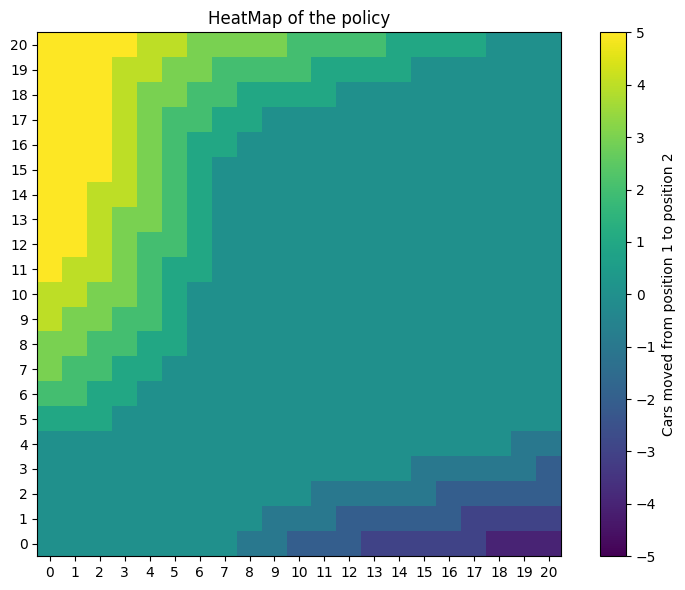

In [13]:
plt.figure(figsize=(8, 6))

im = plt.imshow(
    policy,
    origin='lower',
    cmap='viridis',
    vmin=-5,
    vmax=5
)
plt.xticks(ticks=np.arange(21), labels=np.arange(21))
plt.yticks(ticks=np.arange(21), labels=np.arange(21))

cbar = plt.colorbar(im)
cbar.set_ticks(np.arange(-5, 6, 1))
cbar.set_label('Cars moved from position 1 to position 2')

plt.title('HeatMap of the policy')

plt.tight_layout()
plt.show()